In [1]:
import numpy as np
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing(as_frame=True)
X=housing.data.values.astype(np.float32)
Y=housing.target.values.astype(np.float32)
print(f"Features: {housing.feature_names}")
print(f"Shape: X = {X.shape} | {Y.shape}")
print(f"Targat range: {Y.max():.2f} - {Y.max():.2f} ($100k)")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: X = (20640, 8) | (20640,)
Targat range: 5.00 - 5.00 ($100k)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)
print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")


Train: 8772 | Val: 8772 | Test: 3096


In [3]:
from tensorflow import keras

def build_house_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="features")

    x=keras.layers.Dense(256)(inputs)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation("relu")(x)
    x=keras.layers.Dropout(0.2)(x)

    x=keras.layers.Dense(128)(inputs)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation("relu")(x)
    x=keras.layers.Dropout(0.2)(x)

    x=keras.layers.Dense(64)(inputs)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation("relu")(x)
    x=keras.layers.Dropout(0.2)(x)

    outputs =  x=keras.layers.Dense(1, name="price_output")(x)
    return keras.models.Model(inputs, outputs, name="HousePriceANN")

In [4]:
model=build_house_model(input_dim=8)
model.summary()

Model: "HousePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ price_output (Dense)                 │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 128 (512.00 B)

<h1>COMPILE</h1>

In [15]:
model.compile(
optimizer=keras.optimizers.Adam(learning_rate=1e-3),

loss="mae",
metrics=["mae"]
)

In [16]:
callbacks = [
keras.callbacks.EarlyStopping(
monitor= "val_loss", patience=15,
restore_best_weights=True, verbose=1 # verbose=1 means show me the results at each step
),
keras.callbacks.ReduceLROnPlateau(
monitor= "val_loss", factor=0.5, patience=7,
min_1r=1e-6, verbose=1
),
keras.callbacks.ModelCheckpoint(
"best_house_model.keras", monitor="val_loss",
save_best_only=True, verbose=0
)
]

In [17]:
history=model.fit(
X_train, Y_train,
epochs=200, batch_size=256,
validation_data=(X_val, Y_val),
callbacks=callbacks, verbose=1
)


Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5408 - mae: 0.5408 - val_loss: 0.4819 - val_mae: 0.4819 - learning_rate: 0.0010
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5355 - mae: 0.5355 - val_loss: 0.4846 - val_mae: 0.4846 - learning_rate: 0.0010
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5253 - mae: 0.5253 - val_loss: 0.4853 - val_mae: 0.4853 - learning_rate: 0.0010
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5173 - mae: 0.5173 - val_loss: 0.4859 - val_mae: 0.4859 - learning_rate: 0.0010
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5121 - mae: 0.5121 - val_loss: 0.4932 - val_mae: 0.4932 - learning_rate: 0.0010
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5122 - mae: 0.5122 - val_loss: 0.4828 - val_mae: 0.4828 - learning_rate: 0.0010
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5110 - mae: 0.5110 - val_loss: 0.4869 - val_mae: 0.4869 - learning_rate: 0.0010
Epoch 8/200


In [18]:
from sklearn.metrics import r2_score
results=model.evaluate(X_test, Y_test, verbose=0)
print(f"\n=== TEST RESULTS ===")
print(f"RSE: {results[0]:.4f}")
print(f"RSE: {results[1]:.4f} (${results[1]*100:.0f}k average error)")
Y_pred = model.predict(X_test, verbose=0).flatten()
r2 = r2_score(Y_test, Y_pred)
print(f"R: {r2:.4f} (1.0 = perfect)")


=== TEST RESULTS ===
RSE: 0.4907
RSE: 0.4907 ($49k average error)
R: 0.5889 (1.0 = perfect)


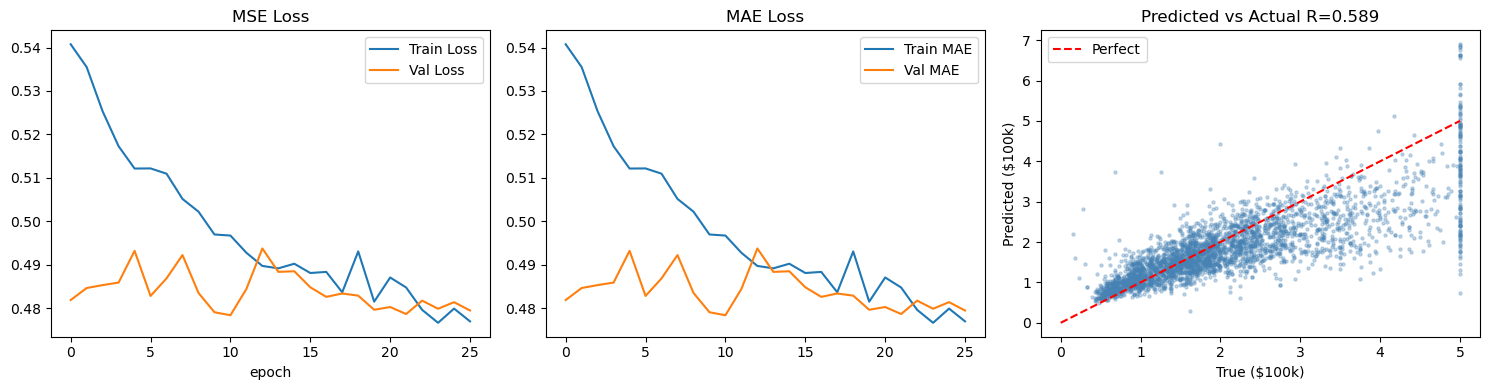

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Loss')
axes[1].legend()
axes[2].scatter(Y_test, Y_pred, alpha=0.3, s=5, color='steelblue')
axes[2].plot([0, 5], [0, 5], 'r--', label='Perfect')
axes[2].set_xlabel('True ($100k)')
axes[2].set_ylabel('Predicted ($100k)')
axes[2].set_title(f"Predicted vs Actual R={r2:.3f}")
axes[2].legend()
plt.tight_layout()
plt.savefig('house_price_results.png', dpi=150)
plt.show()